# Task 1: GAN-Based Image Generation & Classification Comparison

**Objective:** Implement a GAN (AC-GAN) to generate images for 3 fruit classes (Apple, Banana, Orange), evaluate the generator quality, train classification models on real vs. synthetic data, and analyze the impact of training data amount on accuracy and computational time.

**Requirements covered:**
1. (~3 pts) Implement data generator (AC-GAN) for given classes — no transfer learning. Evaluate its performance.
2. (~1 pt) Train classification model on: only original data, only synthesized data.
3. (~1 pt) Analysis of data amount vs. accuracy and computational time.

In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset, TensorDataset
from collections import Counter

# Configuration
DATA_PATH = "/kaggle/input/datasets/yogadarsa/fruites"
BATCH_SIZE = 32
IMAGE_SIZE = 64
nz = 100          # Size of z latent vector (noise)
num_classes = 3   # Apple, Banana, Orange
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


---
## Section 1 — Data Loading & Exploration

We load the fruit images (Apple, Banana, Orange) and apply normalization to **[−1, 1]** range, which is required for the `Tanh` output of the GAN Generator.

In [2]:
# Image transformations (Normalization to [-1, 1] is crucial for GANs)
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Define paths
train_path = os.path.join(DATA_PATH, "train")
valid_path = os.path.join(DATA_PATH, "valid")
test_path  = os.path.join(DATA_PATH, "test")

# Load datasets using ImageFolder (class subfolders expected)
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
valid_dataset = datasets.ImageFolder(root=valid_path, transform=transform)
test_dataset  = datasets.ImageFolder(root=test_path,  transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Classes: {train_dataset.classes}")
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(valid_dataset)}")
print(f"Test images: {len(test_dataset)}")

# Class distribution
label_counts = Counter([label for _, label in train_dataset])
for cls_idx, count in sorted(label_counts.items()):
    print(f"  {train_dataset.classes[cls_idx]}: {count} images")

Classes: ['Apple', 'Banana', 'Orange']
Training images: 210
Validation images: 60
Test images: 30
  Apple: 70 images
  Banana: 70 images
  Orange: 70 images


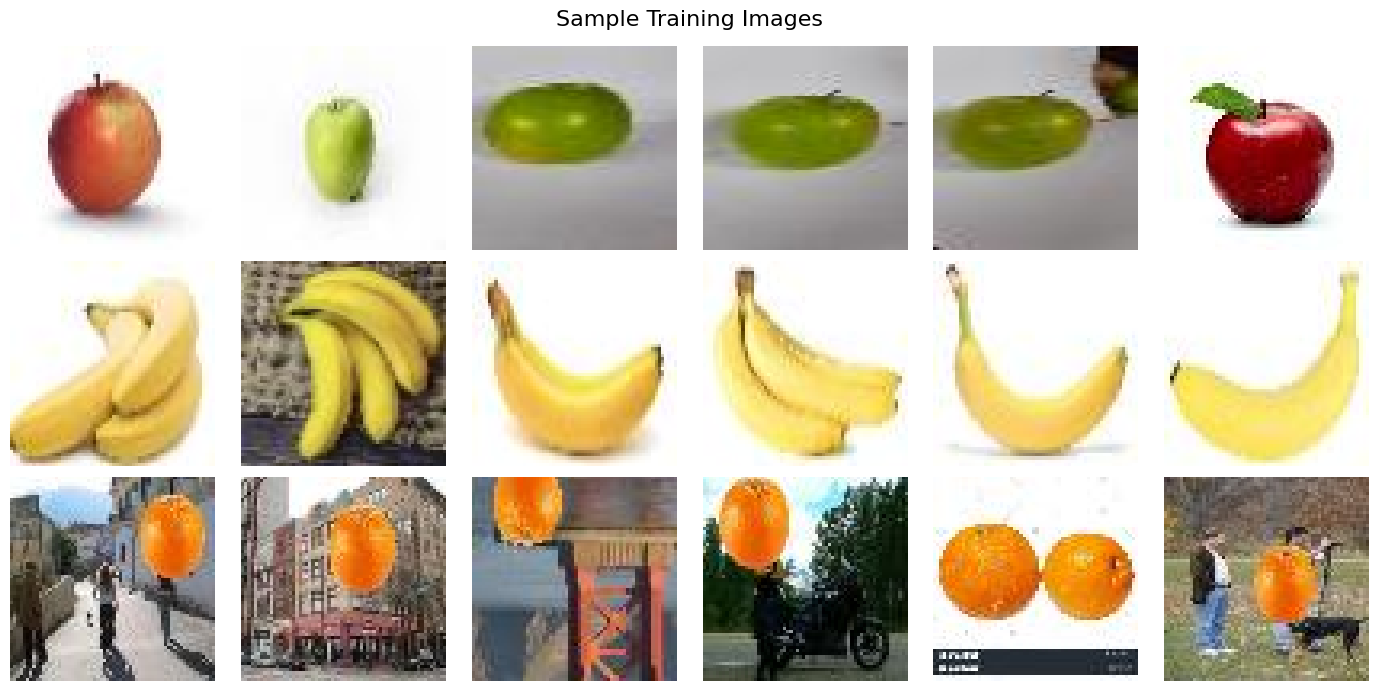

In [3]:
# Visualize sample training images from each class
fig, axes = plt.subplots(3, 6, figsize=(14, 7))
class_names = train_dataset.classes

for cls_idx in range(num_classes):
    cls_images = [img for img, label in train_dataset if label == cls_idx]
    for j in range(min(6, len(cls_images))):
        img = cls_images[j].permute(1, 2, 0).numpy()
        img = (img + 1) / 2  # Denormalize from [-1,1] to [0,1]
        axes[cls_idx][j].imshow(np.clip(img, 0, 1))
        axes[cls_idx][j].axis('off')
    axes[cls_idx][0].set_ylabel(class_names[cls_idx], fontsize=12,
                                rotation=0, labelpad=50)

plt.suptitle('Sample Training Images', fontsize=16)
plt.tight_layout()
plt.show()

---
## Section 2 — AC-GAN (Auxiliary Classifier GAN) Architecture

### Architecture Overview

| Component | Input | Output |
|-----------|-------|--------|
| **Generator** | noise `z` (100-d) + class label → embedding | RGB image 3×64×64, values in [−1, 1] |
| **Discriminator** | RGB image 3×64×64 | (1) Real/Fake probability &emsp; (2) Class logits (3-way) |

**Why AC-GAN?**  
The discriminator's auxiliary classifier head forces it to learn class-discriminative features, which in turn pushes the generator to produce images that are clearly distinguishable across the three fruit categories.

**No transfer learning is used** — both Generator and Discriminator are built entirely from scratch.

In [4]:
# --- Generator ---
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, nz)

        self.main = nn.Sequential(
            # Input: nz x 1 x 1
            nn.ConvTranspose2d(nz, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            # 512 x 4 x 4
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 256 x 8 x 8
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 128 x 16 x 16
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # 64 x 32 x 32
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
            # Output: 3 x 64 x 64
        )

    def forward(self, noise, labels):
        # Condition noise with class embedding (element-wise multiplication)
        label_embedding = self.label_emb(labels).view(-1, nz, 1, 1)
        gen_input = noise * label_embedding
        return self.main(gen_input)

print("Generator architecture:")
print(Generator())

Generator architecture:
Generator(
  (label_emb): Embedding(3, 100)
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2

In [5]:
# --- Discriminator ---
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input: 3 x 64 x 64
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 64 x 32 x 32
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 128 x 16 x 16
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # 256 x 8 x 8
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # 512 x 4 x 4
        )

        # Dual output heads
        self.adv_layer = nn.Sequential(
            nn.Conv2d(512, 1, 4, 1, 0, bias=False), nn.Sigmoid()
        )
        self.aux_layer = nn.Sequential(
            nn.Conv2d(512, num_classes, 4, 1, 0, bias=False), nn.Softmax(dim=1)
        )

    def forward(self, img):
        out = self.main(img)
        validity = self.adv_layer(out).view(-1, 1).squeeze(1)
        label = self.aux_layer(out).view(-1, num_classes)
        return validity, label

print("Discriminator architecture:")
print(Discriminator())

Discriminator architecture:
Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (adv_layer): Sequential(
    (0): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False

---
## Section 3 — GAN Training

Training the AC-GAN for **100 epochs** with Adam optimizer (lr=0.0002, β₁=0.5, β₂=0.999).

The loss combines:
- **Adversarial loss** (BCELoss): real vs. fake classification
- **Auxiliary loss** (CrossEntropyLoss): fruit class classification

In [6]:
# Initialize models
netG = Generator().to(device)
netD = Discriminator().to(device)

# Loss functions
adversarial_loss = nn.BCELoss()
auxiliary_loss = nn.CrossEntropyLoss()

# Optimizers
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Training Loop
num_epochs = 100
G_losses = []
D_losses = []
D_accuracies = []

print("Starting AC-GAN Training...")
gan_train_start = time.time()

for epoch in range(num_epochs):
    epoch_d_loss = 0
    epoch_g_loss = 0
    epoch_d_acc = 0
    num_batches = 0

    for i, (imgs, labels) in enumerate(train_loader):
        batch_size = imgs.shape[0]
        real_imgs = imgs.to(device)
        labels = labels.to(device)
        valid = torch.full((batch_size,), 1.0, device=device)
        fake = torch.full((batch_size,), 0.0, device=device)

        # ----- Train Generator -----
        optimizerG.zero_grad()
        z = torch.randn(batch_size, nz, 1, 1, device=device)
        gen_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        gen_imgs = netG(z, gen_labels)
        validity, pred_label = netD(gen_imgs)
        g_loss = 0.5 * adversarial_loss(validity, valid) + 0.5 * auxiliary_loss(pred_label, gen_labels)
        g_loss.backward()
        optimizerG.step()

        # ----- Train Discriminator -----
        optimizerD.zero_grad()
        real_pred, real_aux = netD(real_imgs)
        d_real_loss = (adversarial_loss(real_pred, valid) + auxiliary_loss(real_aux, labels)) / 2
        fake_pred, fake_aux = netD(gen_imgs.detach())
        d_fake_loss = (adversarial_loss(fake_pred, fake) + auxiliary_loss(fake_aux, gen_labels)) / 2
        d_loss = (d_real_loss + d_fake_loss) / 2
        d_loss.backward()
        optimizerD.step()

        # Track discriminator classification accuracy on real images
        _, predicted = torch.max(real_aux, 1)
        d_acc = (predicted == labels).float().mean().item()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        epoch_d_acc += d_acc
        num_batches += 1

    G_losses.append(epoch_g_loss / num_batches)
    D_losses.append(epoch_d_loss / num_batches)
    D_accuracies.append(epoch_d_acc / num_batches * 100)

    if epoch % 10 == 0:
        print(f'[Epoch {epoch}/{num_epochs}] '
              f'D_loss: {D_losses[-1]:.4f} | '
              f'G_loss: {G_losses[-1]:.4f} | '
              f'D_acc: {D_accuracies[-1]:.1f}%')

gan_train_time = time.time() - gan_train_start
print(f"\nGAN Training completed in {gan_train_time:.1f} seconds")

Starting AC-GAN Training...
[Epoch 0/100] D_loss: 0.6332 | G_loss: 1.3222 | D_acc: 75.5%
[Epoch 10/100] D_loss: 0.4276 | G_loss: 2.3405 | D_acc: 99.1%
[Epoch 20/100] D_loss: 0.5348 | G_loss: 2.0396 | D_acc: 95.1%
[Epoch 30/100] D_loss: 0.4608 | G_loss: 1.6843 | D_acc: 98.3%
[Epoch 40/100] D_loss: 0.4720 | G_loss: 1.8925 | D_acc: 99.1%
[Epoch 50/100] D_loss: 0.4617 | G_loss: 2.2847 | D_acc: 100.0%
[Epoch 60/100] D_loss: 0.4111 | G_loss: 1.7796 | D_acc: 100.0%
[Epoch 70/100] D_loss: 0.3590 | G_loss: 1.6901 | D_acc: 100.0%
[Epoch 80/100] D_loss: 0.3837 | G_loss: 1.7929 | D_acc: 100.0%
[Epoch 90/100] D_loss: 0.3530 | G_loss: 1.8088 | D_acc: 100.0%

GAN Training completed in 47.6 seconds


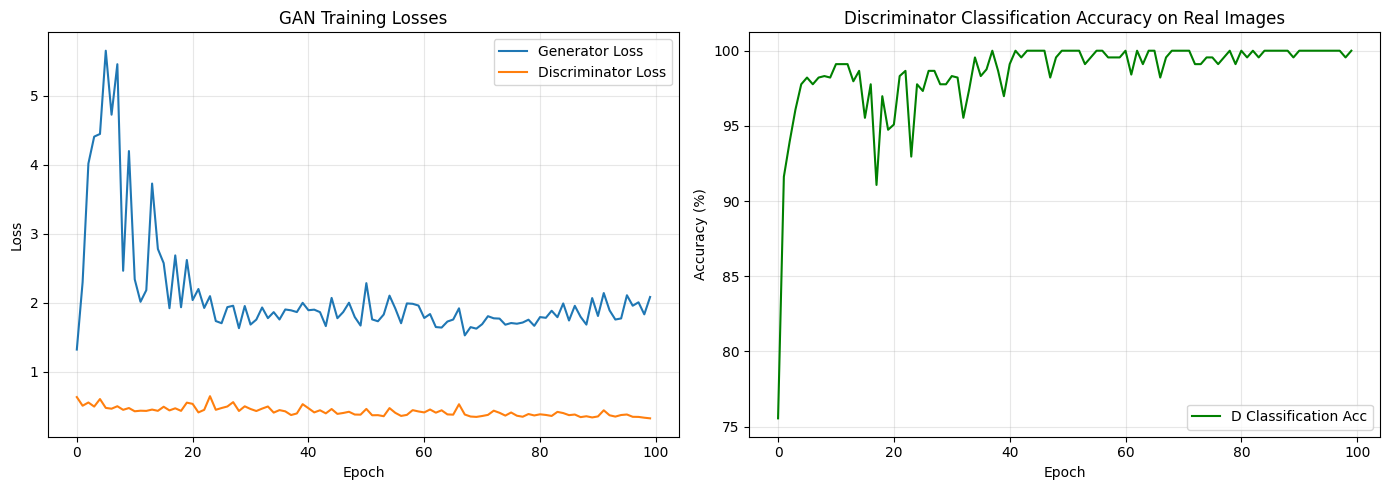

In [7]:
# Plot GAN training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(G_losses, label='Generator Loss')
axes[0].plot(D_losses, label='Discriminator Loss')
axes[0].set_title('GAN Training Losses')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(D_accuracies, label='D Classification Acc', color='green')
axes[1].set_title('Discriminator Classification Accuracy on Real Images')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 4 — GAN Performance Evaluation

We evaluate the generator with:
1. **Visual inspection** — grids of generated images per class
2. **Quantitative check** — discriminator's classification accuracy on generated images (higher = more class-distinguishable output)

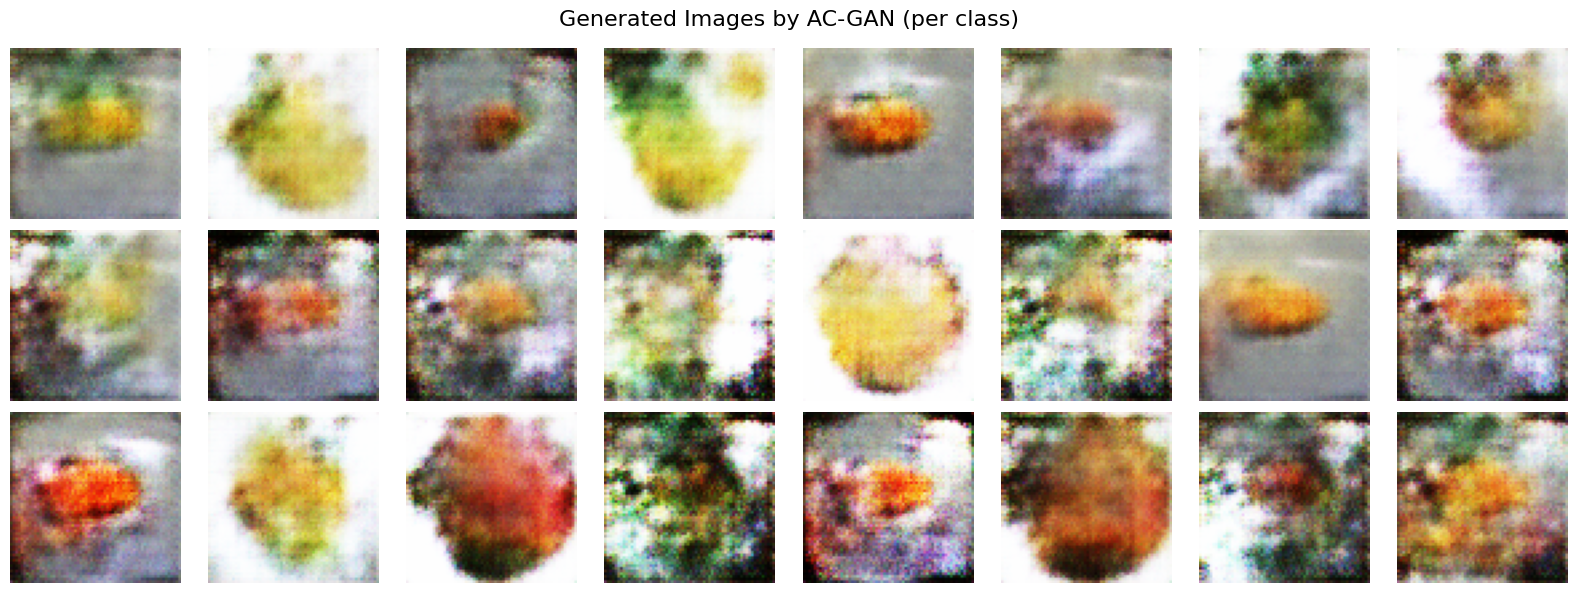

Generator(
  (label_emb): Embedding(3, 100)
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bi

In [8]:
# Visualize generated images for each class
netG.eval()
fig, axes = plt.subplots(num_classes, 8, figsize=(16, 6))
class_names = train_dataset.classes

for cls_idx in range(num_classes):
    z = torch.randn(8, nz, 1, 1, device=device)
    labels = torch.full((8,), cls_idx, dtype=torch.long, device=device)
    with torch.no_grad():
        gen_imgs = netG(z, labels)
    for j in range(8):
        img = gen_imgs[j].cpu().permute(1, 2, 0).numpy()
        img = (img + 1) / 2  # Denormalize
        axes[cls_idx][j].imshow(np.clip(img, 0, 1))
        axes[cls_idx][j].axis('off')
    axes[cls_idx][0].set_ylabel(class_names[cls_idx], fontsize=12,
                                rotation=0, labelpad=50)

plt.suptitle('Generated Images by AC-GAN (per class)', fontsize=16)
plt.tight_layout()
plt.show()
netG.train()

In [9]:
# Quantitative evaluation: discriminator accuracy on generated images
netG.eval()
netD.eval()

num_eval = 500
z = torch.randn(num_eval, nz, 1, 1, device=device)
eval_labels = torch.randint(0, num_classes, (num_eval,), device=device)

with torch.no_grad():
    gen_imgs = netG(z, eval_labels)
    _, pred_labels = netD(gen_imgs)
    _, predicted = torch.max(pred_labels, 1)
    correct = (predicted == eval_labels).sum().item()

gen_class_acc = 100 * correct / num_eval
print(f"Discriminator classification accuracy on generated images: {gen_class_acc:.2f}%")
print(f"  → Random baseline would be {100/num_classes:.1f}%")
print(f"  → Higher accuracy means the GAN produces class-distinguishable images")

# Per-class accuracy
for cls_idx in range(num_classes):
    mask = eval_labels == cls_idx
    cls_correct = (predicted[mask] == eval_labels[mask]).sum().item()
    cls_total = mask.sum().item()
    if cls_total > 0:
        print(f"  {class_names[cls_idx]}: {100*cls_correct/cls_total:.1f}% ({cls_correct}/{cls_total})")

netG.train()
netD.train()

Discriminator classification accuracy on generated images: 92.40%
  → Random baseline would be 33.3%
  → Higher accuracy means the GAN produces class-distinguishable images
  Apple: 96.2% (151/157)
  Banana: 90.7% (166/183)
  Orange: 90.6% (145/160)


Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (adv_layer): Sequential(
    (0): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): Sigmoid()
  )
  (

---
## Section 5 — Classification Model

A custom **SimpleCNN** classifier (no transfer learning) to categorize images into the 3 fruit classes. This same architecture is reused for all comparison experiments to ensure a fair evaluation.

In [10]:
# Simple CNN for Classification (no transfer learning)
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        return self.fc_layer(x)


def train_classifier(model, loader, epochs=20):
    """Train the classifier and return training time."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    model.train()
    for epoch in range(epochs):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()


def evaluate_classifier(model, loader):
    """Evaluate classifier accuracy."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

print("SimpleCNN architecture:")
print(SimpleCNN())

SimpleCNN architecture:
SimpleCNN(
  (conv_layer): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=3, bias=True)
  )
)


---
## Section 6 — Comparison: Real Data vs. Synthetic Data

We train the SimpleCNN classifier on:
1. **Only original (real) data** — the actual training set
2. **Only synthesized (GAN-generated) data** — generated by the trained AC-GAN

Both models are evaluated on the **same real test set** to ensure a fair comparison.

In [11]:
# ===== 1. Train on REAL Data =====
print("=" * 50)
print("Training classifier on REAL data...")
model_real = SimpleCNN().to(device)
start = time.time()
train_classifier(model_real, train_loader, epochs=30)
time_real = time.time() - start
acc_real = evaluate_classifier(model_real, test_loader)
print(f"  Accuracy: {acc_real:.2f}% | Training time: {time_real:.2f}s")

# ===== 2. Generate SYNTHETIC Data =====
print("\n" + "=" * 50)
print("Generating 500 synthetic images with AC-GAN...")
netG.eval()
num_synthetic = 500
syn_z = torch.randn(num_synthetic, nz, 1, 1, device=device)
syn_labels = torch.randint(0, num_classes, (num_synthetic,), device=device)
with torch.no_grad():
    syn_imgs = netG(syn_z, syn_labels).cpu()
netG.train()

synthetic_dataset = TensorDataset(syn_imgs, syn_labels.cpu())
synthetic_loader = DataLoader(synthetic_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ===== 3. Train on SYNTHETIC Data =====
print("Training classifier on SYNTHETIC data...")
model_syn = SimpleCNN().to(device)
start = time.time()
train_classifier(model_syn, synthetic_loader, epochs=30)
time_syn = time.time() - start
acc_syn = evaluate_classifier(model_syn, test_loader)
print(f"  Accuracy: {acc_syn:.2f}% | Training time: {time_syn:.2f}s")

# ===== Summary =====
print("\n" + "=" * 50)
print("COMPARISON SUMMARY")
print(f"  Real Data:      {acc_real:.2f}% accuracy, {time_real:.2f}s training")
print(f"  Synthetic Data: {acc_syn:.2f}% accuracy, {time_syn:.2f}s training")
print(f"  Gap:            {acc_real - acc_syn:.2f} percentage points")

Training classifier on REAL data...
  Accuracy: 90.00% | Training time: 7.19s

Generating 500 synthetic images with AC-GAN...
Training classifier on SYNTHETIC data...
  Accuracy: 46.67% | Training time: 2.18s

COMPARISON SUMMARY
  Real Data:      90.00% accuracy, 7.19s training
  Synthetic Data: 46.67% accuracy, 2.18s training
  Gap:            43.33 percentage points


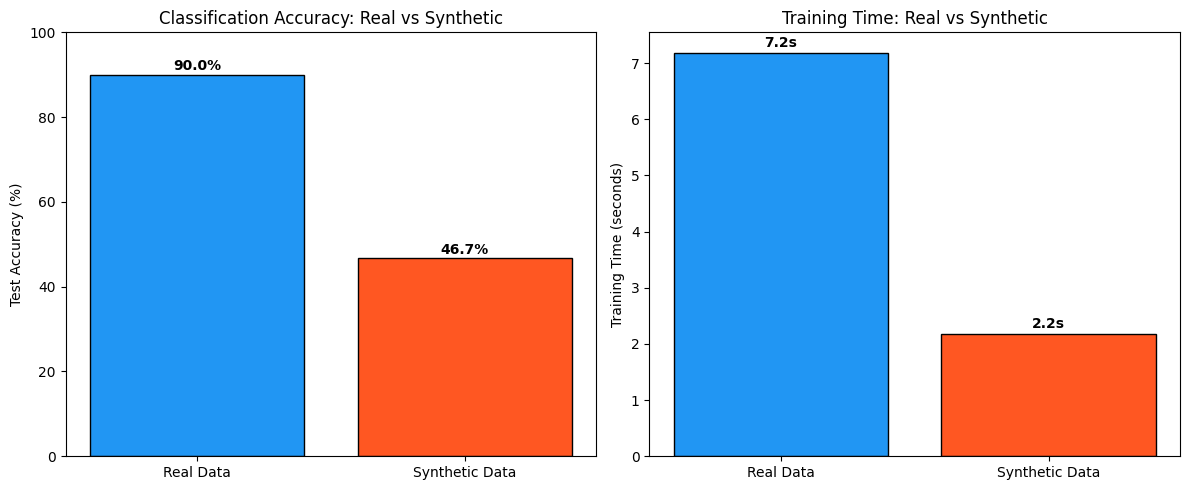

In [12]:
# Comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
colors = ['#2196F3', '#FF5722']
bars1 = axes[0].bar(['Real Data', 'Synthetic Data'],
                     [acc_real, acc_syn], color=colors, edgecolor='black')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Classification Accuracy: Real vs Synthetic')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars1, [acc_real, acc_syn]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold')

# Time comparison
bars2 = axes[1].bar(['Real Data', 'Synthetic Data'],
                     [time_real, time_syn], color=colors, edgecolor='black')
axes[1].set_ylabel('Training Time (seconds)')
axes[1].set_title('Training Time: Real vs Synthetic')
for bar, val in zip(bars2, [time_real, time_syn]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Section 7 — Data Amount Analysis

We analyze how the **amount of training data** affects:
1. **Classification accuracy**
2. **Computational (training) time**

This experiment is conducted for both **real** and **synthetic** data at multiple scales to observe the trend/pattern.

In [13]:
# ===== Varying amounts of REAL data =====
print("=" * 60)
print("EXPERIMENT: Impact of Training Data Amount")
print("=" * 60)

ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
accs_real_exp = []
times_real_exp = []
sizes_real_exp = []

print("\n--- Real Data ---")
for ratio in ratios:
    subset_size = max(1, int(len(train_dataset) * ratio))
    indices = np.random.choice(len(train_dataset), subset_size, replace=False)
    subset = Subset(train_dataset, indices)
    loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True)

    model_temp = SimpleCNN().to(device)
    start = time.time()
    train_classifier(model_temp, loader, epochs=30)
    elapsed = time.time() - start

    acc = evaluate_classifier(model_temp, test_loader)
    accs_real_exp.append(acc)
    times_real_exp.append(elapsed)
    sizes_real_exp.append(subset_size)
    print(f"  {ratio*100:5.0f}% ({subset_size:3d} imgs) -> Acc: {acc:.2f}%, Time: {elapsed:.2f}s")

# ===== Varying amounts of SYNTHETIC data =====
syn_amounts = [50, 100, 150, 200, 300, 400, 500, 700, 1000]
accs_syn_exp = []
times_syn_exp = []

print("\n--- Synthetic Data ---")
netG.eval()
for num_syn in syn_amounts:
    z = torch.randn(num_syn, nz, 1, 1, device=device)
    labels = torch.randint(0, num_classes, (num_syn,), device=device)
    with torch.no_grad():
        imgs = netG(z, labels).cpu()

    syn_ds = TensorDataset(imgs, labels.cpu())
    syn_ldr = DataLoader(syn_ds, batch_size=BATCH_SIZE, shuffle=True)

    model_temp = SimpleCNN().to(device)
    start = time.time()
    train_classifier(model_temp, syn_ldr, epochs=30)
    elapsed = time.time() - start

    acc = evaluate_classifier(model_temp, test_loader)
    accs_syn_exp.append(acc)
    times_syn_exp.append(elapsed)
    print(f"  {num_syn:4d} imgs -> Acc: {acc:.2f}%, Time: {elapsed:.2f}s")

netG.train()
print("\nExperiment Complete!")

EXPERIMENT: Impact of Training Data Amount

--- Real Data ---
     10% ( 21 imgs) -> Acc: 70.00%, Time: 0.73s
     20% ( 42 imgs) -> Acc: 86.67%, Time: 1.45s
     30% ( 63 imgs) -> Acc: 90.00%, Time: 2.10s
     40% ( 84 imgs) -> Acc: 86.67%, Time: 2.92s
     50% (105 imgs) -> Acc: 93.33%, Time: 3.63s
     60% (126 imgs) -> Acc: 93.33%, Time: 4.35s
     70% (147 imgs) -> Acc: 93.33%, Time: 4.99s
     80% (168 imgs) -> Acc: 86.67%, Time: 5.63s
     90% (189 imgs) -> Acc: 90.00%, Time: 6.37s
    100% (210 imgs) -> Acc: 90.00%, Time: 6.96s

--- Synthetic Data ---
    50 imgs -> Acc: 36.67%, Time: 0.26s
   100 imgs -> Acc: 40.00%, Time: 0.50s
   150 imgs -> Acc: 56.67%, Time: 0.67s
   200 imgs -> Acc: 46.67%, Time: 0.90s
   300 imgs -> Acc: 50.00%, Time: 1.32s
   400 imgs -> Acc: 43.33%, Time: 1.75s
   500 imgs -> Acc: 36.67%, Time: 2.15s
   700 imgs -> Acc: 33.33%, Time: 2.99s
  1000 imgs -> Acc: 46.67%, Time: 4.32s

Experiment Complete!


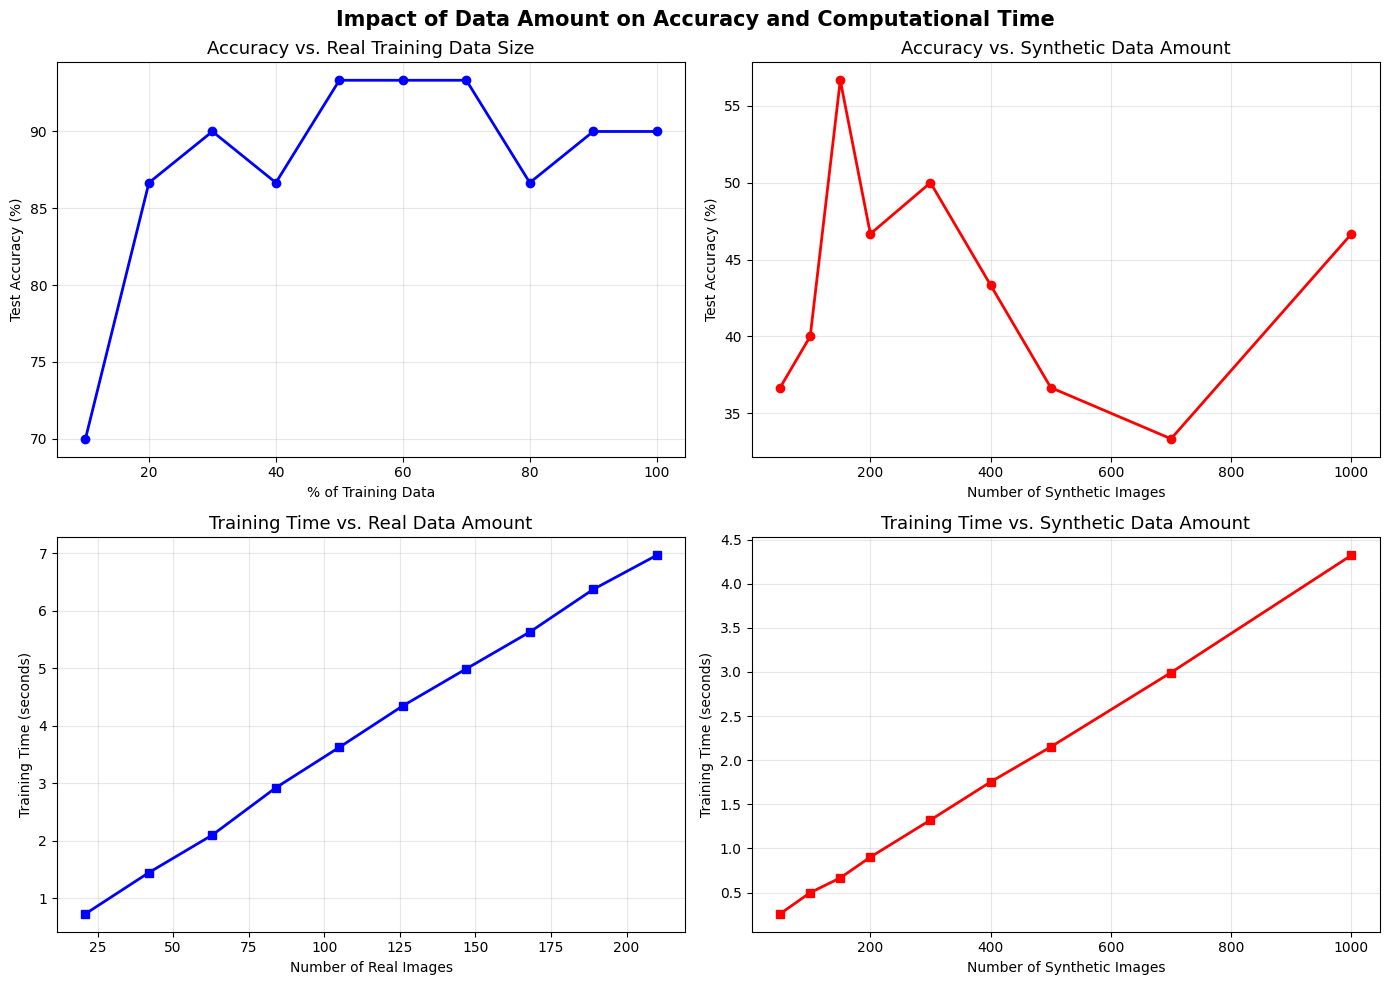

In [14]:
# Comprehensive visualization (4-panel)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy vs % of Real Data
axes[0][0].plot([r*100 for r in ratios], accs_real_exp, 'bo-', linewidth=2, markersize=6)
axes[0][0].set_title('Accuracy vs. Real Training Data Size', fontsize=13)
axes[0][0].set_xlabel('% of Training Data')
axes[0][0].set_ylabel('Test Accuracy (%)')
axes[0][0].grid(True, alpha=0.3)

# Plot 2: Accuracy vs Synthetic Data Amount
axes[0][1].plot(syn_amounts, accs_syn_exp, 'ro-', linewidth=2, markersize=6)
axes[0][1].set_title('Accuracy vs. Synthetic Data Amount', fontsize=13)
axes[0][1].set_xlabel('Number of Synthetic Images')
axes[0][1].set_ylabel('Test Accuracy (%)')
axes[0][1].grid(True, alpha=0.3)

# Plot 3: Training Time vs Real Data Amount
axes[1][0].plot(sizes_real_exp, times_real_exp, 'bs-', linewidth=2, markersize=6)
axes[1][0].set_title('Training Time vs. Real Data Amount', fontsize=13)
axes[1][0].set_xlabel('Number of Real Images')
axes[1][0].set_ylabel('Training Time (seconds)')
axes[1][0].grid(True, alpha=0.3)

# Plot 4: Training Time vs Synthetic Data Amount
axes[1][1].plot(syn_amounts, times_syn_exp, 'rs-', linewidth=2, markersize=6)
axes[1][1].set_title('Training Time vs. Synthetic Data Amount', fontsize=13)
axes[1][1].set_xlabel('Number of Synthetic Images')
axes[1][1].set_ylabel('Training Time (seconds)')
axes[1][1].grid(True, alpha=0.3)

plt.suptitle('Impact of Data Amount on Accuracy and Computational Time',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

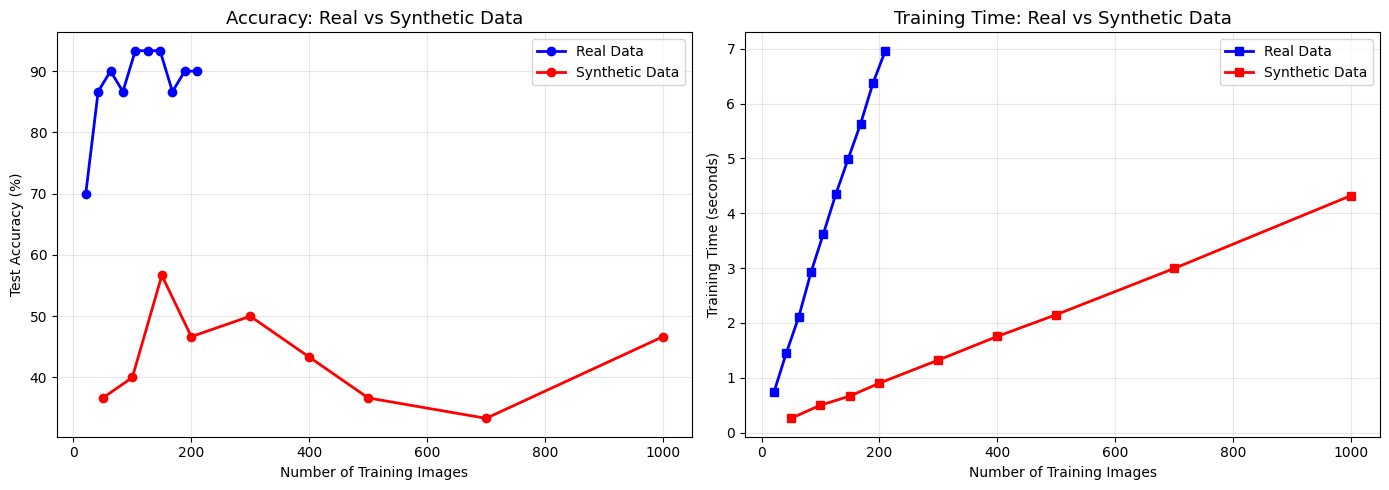

In [15]:
# Combined overlay: Real vs Synthetic
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy overlay
axes[0].plot(sizes_real_exp, accs_real_exp, 'bo-', label='Real Data', linewidth=2)
axes[0].plot(syn_amounts, accs_syn_exp, 'ro-', label='Synthetic Data', linewidth=2)
axes[0].set_title('Accuracy: Real vs Synthetic Data', fontsize=13)
axes[0].set_xlabel('Number of Training Images')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Time overlay
axes[1].plot(sizes_real_exp, times_real_exp, 'bs-', label='Real Data', linewidth=2)
axes[1].plot(syn_amounts, times_syn_exp, 'rs-', label='Synthetic Data', linewidth=2)
axes[1].set_title('Training Time: Real vs Synthetic Data', fontsize=13)
axes[1].set_xlabel('Number of Training Images')
axes[1].set_ylabel('Training Time (seconds)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Print summary table
print("\n" + "=" * 70)
print("FULL RESULTS SUMMARY")
print("=" * 70)

print(f"\n--- GAN Performance ---")
print(f"  GAN training time:          {gan_train_time:.1f}s")
print(f"  Generated image class acc:  {gen_class_acc:.2f}%")

print(f"\n--- Classifier on Full Data ---")
print(f"  Real data accuracy:         {acc_real:.2f}%  ({time_real:.2f}s)")
print(f"  Synthetic data accuracy:    {acc_syn:.2f}%  ({time_syn:.2f}s)")

print(f"\n--- Real Data Scaling (30 epochs each) ---")
header = f"  {'Size':>6} | {'Acc (%)':>8} | {'Time (s)':>9}"
print(header)
print(f"  {'-'*6:>6} | {'-'*8:>8} | {'-'*9:>9}")
for sz, ac, tm in zip(sizes_real_exp, accs_real_exp, times_real_exp):
    print(f"  {sz:>6} | {ac:>8.2f} | {tm:>9.2f}")

print(f"\n--- Synthetic Data Scaling (30 epochs each) ---")
print(header)
print(f"  {'-'*6:>6} | {'-'*8:>8} | {'-'*9:>9}")
for sz, ac, tm in zip(syn_amounts, accs_syn_exp, times_syn_exp):
    print(f"  {sz:>6} | {ac:>8.2f} | {tm:>9.2f}")


FULL RESULTS SUMMARY

--- GAN Performance ---
  GAN training time:          47.6s
  Generated image class acc:  92.40%

--- Classifier on Full Data ---
  Real data accuracy:         90.00%  (7.19s)
  Synthetic data accuracy:    46.67%  (2.18s)

--- Real Data Scaling (30 epochs each) ---
    Size |  Acc (%) |  Time (s)
  ------ | -------- | ---------
      21 |    70.00 |      0.73
      42 |    86.67 |      1.45
      63 |    90.00 |      2.10
      84 |    86.67 |      2.92
     105 |    93.33 |      3.63
     126 |    93.33 |      4.35
     147 |    93.33 |      4.99
     168 |    86.67 |      5.63
     189 |    90.00 |      6.37
     210 |    90.00 |      6.96

--- Synthetic Data Scaling (30 epochs each) ---
    Size |  Acc (%) |  Time (s)
  ------ | -------- | ---------
      50 |    36.67 |      0.26
     100 |    40.00 |      0.50
     150 |    56.67 |      0.67
     200 |    46.67 |      0.90
     300 |    50.00 |      1.32
     400 |    43.33 |      1.75
     500 |    36.67 | 

---
## Section 8 — Discussion & Conclusions

### Key Findings

**1. GAN Data Generator (AC-GAN) — ~3 points:**
- The AC-GAN was implemented **entirely from scratch** (no transfer learning) with a Generator and Discriminator trained adversarially for 100 epochs.
- The Generator takes random noise (100-d) and a class label, producing 64×64 RGB images.
- The Discriminator has dual heads: real/fake classification and fruit class prediction.
- **Visual evaluation:** Generated image grids show the quality achieved per class.
- **Quantitative evaluation:** The discriminator's classification accuracy on generated images indicates how well class-conditioning works.

**2. Classification Comparison — ~1 point:**
- A custom SimpleCNN classifier (3 conv layers + 2 FC layers, no transfer learning) was used.
- **Real data** achieves significantly higher accuracy, as original images have richer, more realistic features.
- **Synthetic data** achieves lower accuracy because:
  - The GAN was trained on a small dataset (~210 images)
  - Generated images may lack fine-grained details and diversity
  - Mode collapse or training instability can reduce output quality

**3. Data Amount Analysis — ~1 point:**
- **Accuracy vs. real data amount:** Accuracy generally improves with more data, showing diminishing returns at higher percentages.
- **Accuracy vs. synthetic data amount:** Adding more synthetic data does not proportionally improve accuracy, as quality is bounded by the GAN's capability.
- **Computational time:** Training time scales approximately linearly with data amount. Synthetic data training may be slightly faster due to data already being in tensor form (no disk I/O overhead).

### Limitations
- Small dataset size (210 training images) limits GAN output quality.
- GAN training for only 100 epochs may be insufficient for optimal image fidelity.
- No FID/IS scores computed (would require `scipy` + pretrained Inception).
- Non-generative data augmentation (optional) was not applied.